PAREENITA A.SHIRSATH B.E.A.I.&.D.S.  ROLL.NO:49

AIFBA EXPERIMENT: 09

/tmp/ipykernel_646/4183534868.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Cumulative Return: 28.08%
Sharpe Ratio: 0.5
Max Drawdown: -17.15%


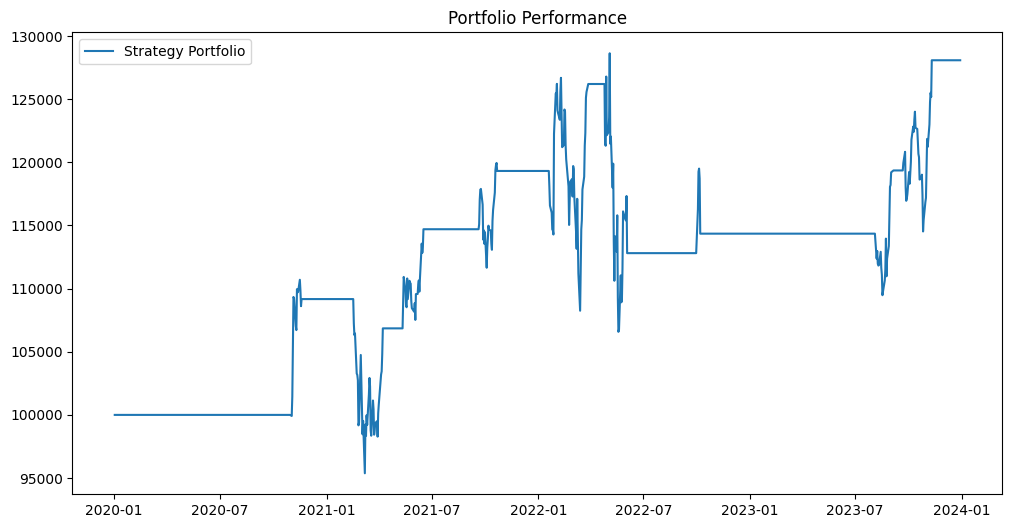

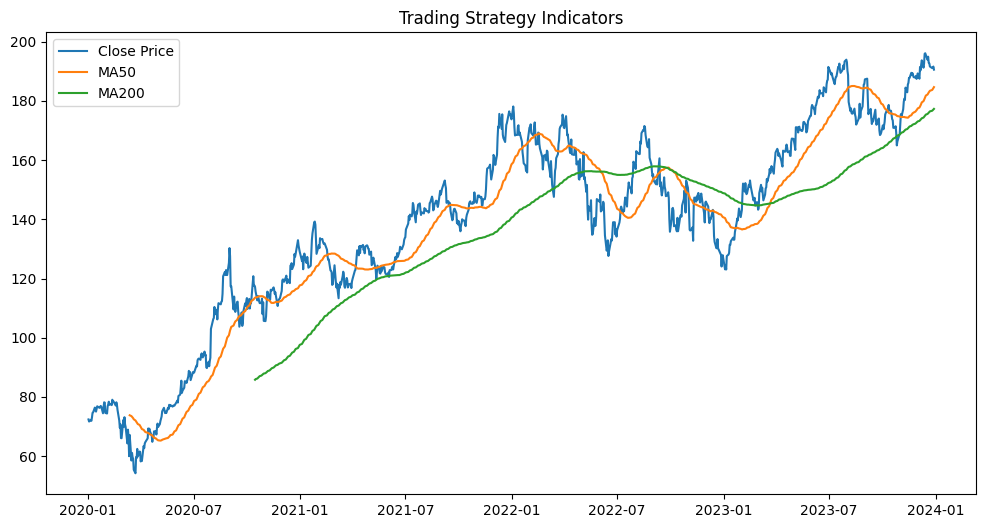

In [2]:
# ==========================================
# STEP 1: Install Required Libraries
# ==========================================
!pip install yfinance pandas numpy matplotlib

# ==========================================
# STEP 2: Import Libraries
# ==========================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# STEP 3: Load Historical Data
# ==========================================
# Example: Apple stock (you can change)
data = yf.download('AAPL', start='2020-01-01', end='2024-01-01')

# ==========================================
# STEP 4: Calculate Indicators
# ==========================================

# Moving Averages
data['MA50'] = data['Close'].rolling(window=50).mean()
data['MA200'] = data['Close'].rolling(window=200).mean()

# RSI Function
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

data['RSI'] = compute_rsi(data['Close'])

# ==========================================
# STEP 5: Define Trading Strategy
# ==========================================

# Buy Signal:
# MA50 > MA200 AND RSI < 30 (oversold)
# Sell Signal:
# MA50 < MA200 OR RSI > 70 (overbought)

data['Signal'] = 0

data.loc[(data['MA50'] > data['MA200']) & (data['RSI'] < 30), 'Signal'] = 1
data.loc[(data['MA50'] < data['MA200']) | (data['RSI'] > 70), 'Signal'] = -1

# ==========================================
# STEP 6: Backtesting Logic
# ==========================================

initial_capital = 100000
capital = initial_capital
position = 0
portfolio_value = []

for i in range(len(data)):
    price = data['Close'].iloc[i].item() # Modified: .item() added here to get scalar
    signal = data['Signal'].iloc[i]

    # Buy
    if signal == 1 and capital > 0:
        position = capital / price
        capital = 0

    # Sell
    elif signal == -1 and position > 0:
        capital = position * price
        position = 0

    # Portfolio value
    total_value = capital + (position * price)
    portfolio_value.append(total_value)

data['Portfolio'] = portfolio_value

# ==========================================
# STEP 7: Performance Metrics
# ==========================================

# Returns
data['Returns'] = data['Portfolio'].pct_change()

# Cumulative Return
cumulative_return = (data['Portfolio'].iloc[-1] / initial_capital - 1) * 100

# Sharpe Ratio
sharpe_ratio = (data['Returns'].mean() / data['Returns'].std()) * np.sqrt(252)

# Max Drawdown
roll_max = data['Portfolio'].cummax()
drawdown = data['Portfolio'] / roll_max - 1
max_drawdown = drawdown.min() * 100

print("Cumulative Return: {:.2f}%".format(cumulative_return))
print("Sharpe Ratio:", round(sharpe_ratio, 2))
print("Max Drawdown: {:.2f}%".format(max_drawdown))

# ==========================================
# STEP 8: Visualization
# ==========================================

plt.figure(figsize=(12,6))
plt.plot(data['Portfolio'], label='Strategy Portfolio')
plt.title("Portfolio Performance")
plt.legend()
plt.show()

# Price + Indicators
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['MA50'], label='MA50')
plt.plot(data['MA200'], label='MA200')
plt.legend()
plt.title("Trading Strategy Indicators")
plt.show()